# Claim 1 (rank version): Input content causally shapes answer rank

Mirrors the accuracy notebook but uses **answer rank** as the dependent variable. Rank = number of logits strictly above the correct answer's first-token logit. Rank 0 means the correct answer is the top prediction.

Rank distributions are heavy-tailed, so we report **median + IQR** rather than mean + CI. Bootstrap CIs are on the median.

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-13 17:50:31.949772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.02it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build the input pools and donor task mapping

In [2]:
W_E = model.W_E.detach()

input_pool_all = []
input_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            input_pool_all.append(inp)
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            input_pool_all_tokids.append(toks[0].item())

mean_input_embed = W_E[input_pool_all_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {}
for i, t in enumerate(task_list):
    donor_task[t] = task_list[(i + len(task_list) // 2) % len(task_list)]

print('Task → donor mapping:')
for t, d in donor_task.items():
    print(f'  {t:<40} ← {d}')
# Related donor task: for each task T, find the task T' whose inputs are
# most cosine-similar to T's inputs in embedding space. Used for the
# 'related-wrong-task inputs' condition (category-nearby but wrong task).
task_input_tokids = {}
for t, splits in all_splits.items():
    tok_ids = []
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            tok_ids.append(toks[0].item())
    task_input_tokids[t] = tok_ids

# Mean embedding per task
task_mean_emb = {t: W_E[ids].mean(dim=0).float() for t, ids in task_input_tokids.items()}

related_donor_task = {}
for t in task_list:
    t_emb = task_mean_emb[t]
    best_sim = -float('inf')
    best_other = None
    for other in task_list:
        if other == t: continue
        sim = torch.nn.functional.cosine_similarity(t_emb, task_mean_emb[other], dim=0).item()
        if sim > best_sim:
            best_sim = sim
            best_other = other
    related_donor_task[t] = best_other

print('\nTask → RELATED donor mapping (highest embedding-space similarity):')
for t, d in related_donor_task.items():
    print(f'  {t:<40} ← {d}')


Task → donor mapping:
  knowledge/country_capital                ← linguistic/present_simple_gerund
  knowledge/football_player_position       ← linguistic/present_simple_past_perfect
  knowledge/location_continent             ← linguistic/present_simple_past_simple
  knowledge/location_country               ← linguistic/singular_plural
  knowledge/location_language              ← translation/en_es
  knowledge/location_religion              ← translation/en_fr
  knowledge/person_language                ← translation/en_it
  knowledge/person_profession              ← translation/es_en
  linguistic/antonyms                      ← translation/fr_en
  linguistic/plural_singular               ← translation/it_en
  linguistic/present_simple_gerund         ← knowledge/country_capital
  linguistic/present_simple_past_perfect   ← knowledge/football_player_position
  linguistic/present_simple_past_simple    ← knowledge/location_continent
  linguistic/singular_plural               ← knowledge/loc

## Collect all conditions (prompt-level matched)

In [3]:
CONDS = ['orig', 'shuffled', 'related_wrong_task_inputs', 'wrong_task_inputs', 'random_from_input_pool', 'mean_embed', 'star']
ranks = {c: [] for c in CONDS}
prompt_task = []

def answer_rank(model, logits, answer):
    ans_tok = model.to_tokens(' ' + answer, prepend_bos=False)[0, 0].item()
    return int((logits > logits[ans_tok]).sum().item())

def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

for task_name, splits in tqdm(list(all_splits.items())):
    donor_prompts         = all_splits[donor_task[task_name]]['icl_prompts']
    related_donor_prompts = all_splits[related_donor_task[task_name]]['icl_prompts']
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:10]):
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        outputs = [o for _, o in demos]
        inputs  = [i for i, _ in demos]
        
        inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
        
        donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
        inputs_wrong = [i for i, _ in donor_pdata['demo_pairs']]
        if len(inputs_wrong) < len(demos):
            inputs_wrong = (inputs_wrong * ((len(demos) // len(inputs_wrong)) + 1))[:len(demos)]
        inputs_wrong = inputs_wrong[:len(demos)]
        
        rel_pdata = related_donor_prompts[p_idx % len(related_donor_prompts)]
        inputs_related = [i for i, _ in rel_pdata['demo_pairs']]
        if len(inputs_related) < len(demos):
            inputs_related = (inputs_related * ((len(demos) // len(inputs_related)) + 1))[:len(demos)]
        inputs_related = inputs_related[:len(demos)]
        
        inputs_random = [rng.choice(input_pool_all) for _ in range(len(demos))]
        
        prompts = {
            'orig':     pdata['prompt'],
            'shuffled': build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
            'related_wrong_task_inputs': build_icl_prompt(list(zip(inputs_related, outputs)), qi),
            'wrong_task_inputs':         build_icl_prompt(list(zip(inputs_wrong, outputs)), qi),
            'random_from_input_pool':    build_icl_prompt(list(zip(inputs_random, outputs)), qi),
            'star':     build_icl_prompt([('*', o) for o in outputs], qi),
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        lasts  = {k: v.shape[1]-1 for k, v in tokens.items()}
        
        for k in ['orig', 'shuffled', 'related_wrong_task_inputs', 'wrong_task_inputs', 'random_from_input_pool', 'star']:
            with torch.no_grad():
                logits = model(tokens[k])[0, lasts[k]]
            ranks[k].append(answer_rank(model, logits, ans))
        
        per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
        input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
        hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
        with torch.no_grad(), model.hooks(fwd_hooks=hook):
            logits = model(tokens['orig'])[0, lasts['orig']]
        ranks['mean_embed'].append(answer_rank(model, logits, ans))
        
        prompt_task.append(task_name)
        torch.cuda.empty_cache()

for c in CONDS:
    ranks[c] = np.array(ranks[c])
prompt_task = np.array(prompt_task)
total_n = len(prompt_task)
print(f'\nTotal prompts scored: {total_n}')

100%|██████████| 20/20 [00:48<00:00,  2.42s/it]


Total prompts scored: 200


## Marginal accuracies + aggregate plot

/tmp/ipykernel_2817202/1923241075.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x='Condition', y='Rank', order=order_labels,


Condition                      Mean   Median
--------------------------------------------
orig                            0.8      0.0
shuffled                       46.0      3.0
wrong_task_inputs             127.3      5.0
random_from_input_pool        176.3     19.5
mean_embed                    298.2      6.0
star                           31.2      2.0


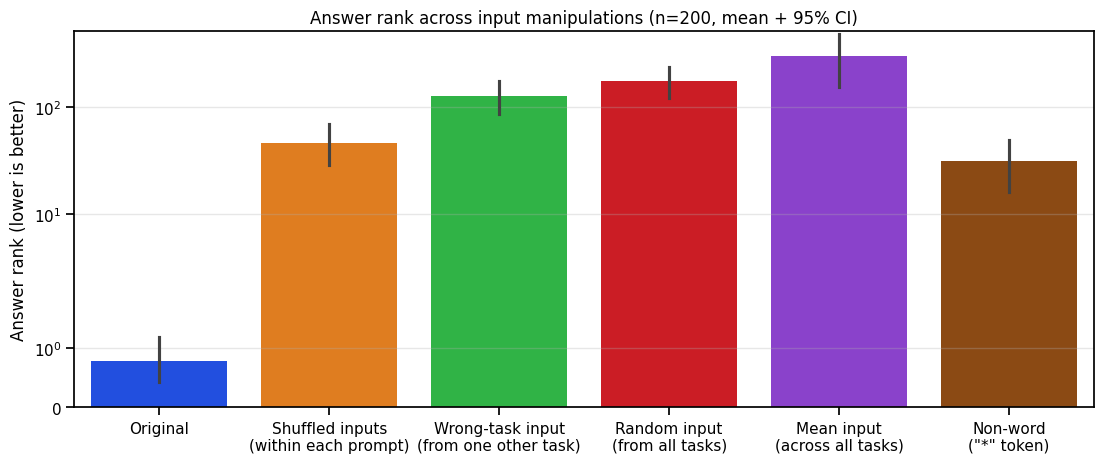

In [4]:
print(f'{"Condition":<26} {"Mean":>8} {"Median":>8}')
print('-' * 44)
for c in CONDS:
    print(f'{c:<26} {ranks[c].mean():>8.1f} {np.median(ranks[c]):>8.1f}')

tick_map = {
    'orig': 'Original',
    'shuffled': 'Shuffled inputs\n(within each prompt)',
    'related_wrong_task_inputs': 'Related wrong-task input\n(from closest other task)',
    'wrong_task_inputs': 'Wrong-task input\n(from one other task)',
    'random_from_input_pool': 'Random input\n(from all tasks)',
    'mean_embed': 'Mean input\n(across all tasks)',
    'star': 'Non-word\n("*" token)',
}
order_keys = CONDS
order_labels = [tick_map[k] for k in order_keys]

df_long = pd.DataFrame({
    'Condition': np.concatenate([[tick_map[c]] * total_n for c in order_keys]),
    'Rank':      np.concatenate([ranks[c] for c in order_keys]),
})

fig, ax = plt.subplots(figsize=(6.4*1.75, 4.8))
sns.barplot(data=df_long, x='Condition', y='Rank', order=order_labels,
            palette='bright', errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('Answer rank (lower is better)')
ax.set_xlabel('')
ax.set_yscale('symlog')
ax.set_title(f'Answer rank across input manipulations (n={total_n}, mean + 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

/tmp/ipykernel_2817202/1740795684.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Rank', order=order_labels,
/tmp/ipykernel_2817202/1740795684.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Rank', order=order_labels,
/tmp/ipykernel_2817202/1740795684.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Rank', order=order_labels,
/tmp/ipykernel_2817202/1740795684.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

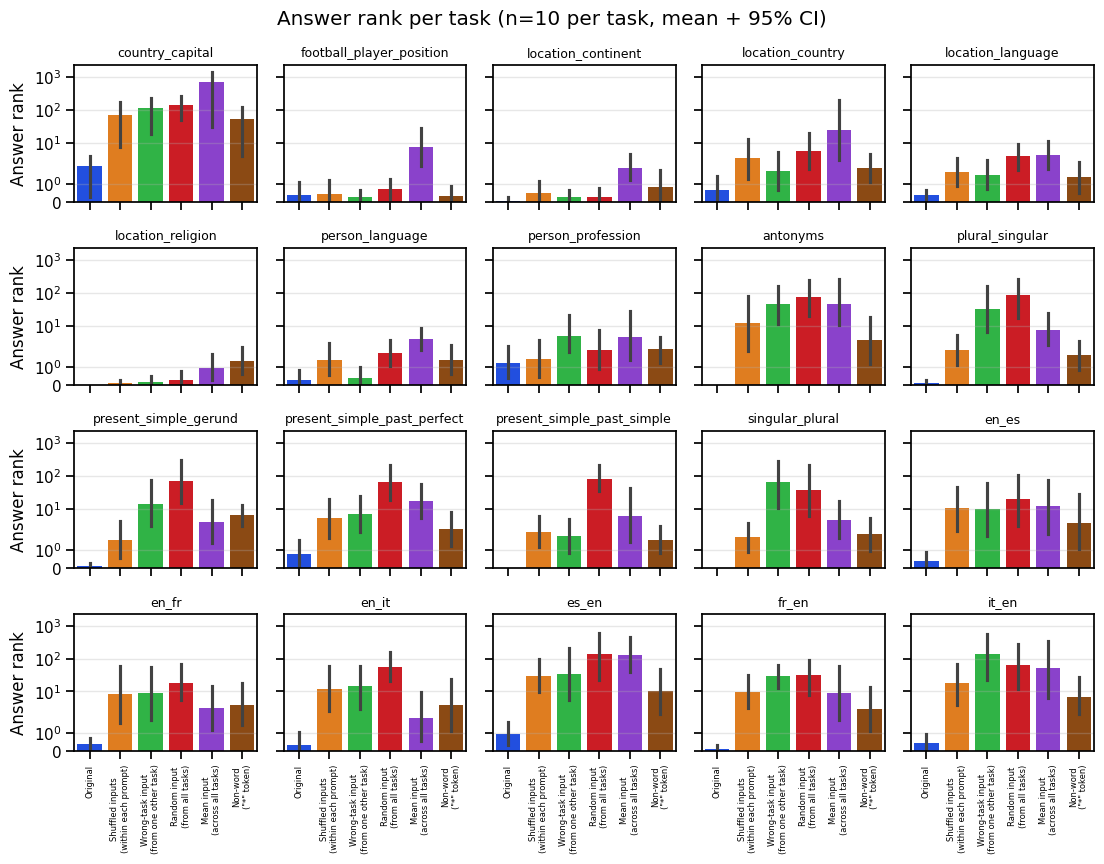

In [5]:
task_list = sorted(set(prompt_task))
n_cols = 5
n_rows = int(np.ceil(len(task_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list):
    mask = prompt_task == t
    df_t = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * mask.sum() for c in order_keys]),
        'Rank':      np.concatenate([ranks[c][mask] for c in order_keys]),
    })
    sns.barplot(data=df_t, x='Condition', y='Rank', order=order_labels,
                palette='bright', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Answer rank' if ax in axes[::n_cols] else '')
    ax.set_yscale('symlog')
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)
    ax.grid(True, alpha=0.3, axis='y')

for ax in axes[len(task_list):]:
    ax.set_visible(False)

fig.suptitle(f'Answer rank per task (n={mask.sum()} per task, mean + 95% CI)')
plt.tight_layout()
plt.show()

## Pairwise prompt-level differences (bootstrap CIs)

In [6]:
COMPARISONS = [
    ('orig', 'shuffled',                                    'Original vs.\nShuffled'),
    ('shuffled', 'related_wrong_task_inputs',              'Shuffled vs.\nRelated wrong-task input'),
    ('related_wrong_task_inputs', 'wrong_task_inputs',      'Related wrong-task input vs.\nWrong-task input'),
    ('wrong_task_inputs', 'random_from_input_pool',         'Wrong-task input vs.\nRandom input'),
    ('random_from_input_pool', 'mean_embed',                'Random input vs.\nMean input'),
    ('mean_embed', 'star',                                  'Mean input vs.\nNon-word'),
]

N_BOOT = 5000
boot_rng = np.random.default_rng(42)

def bootstrap_mean_diff_ci(a, b, n_boot=N_BOOT, ci=0.95):
    d = a - b
    n = len(d)
    means = np.empty(n_boot)
    for i in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        means[i] = d[idx].mean()
    lo = np.percentile(means, 100 * (1 - ci) / 2)
    hi = np.percentile(means, 100 * (1 + ci) / 2)
    return d.mean(), lo, hi

diff_results = []
print(f'{"Comparison":<50} {"Δ mean":>10} {"[95% bootstrap CI]":>26}')
print('-' * 92)
for a, b, label in COMPARISONS:
    m, lo, hi = bootstrap_mean_diff_ci(ranks[a], ranks[b])
    diff_results.append((a, b, label, m, lo, hi))
    print(f'{a} − {b:<30} {m:>+10.1f}   [{lo:>+8.1f}, {hi:>+8.1f}]')

Comparison                                             Δ mean         [95% bootstrap CI]
--------------------------------------------------------------------------------------------
orig − shuffled                            -45.2   [   -66.6,    -27.3]
shuffled − wrong_task_inputs                   -81.3   [  -119.9,    -47.7]
wrong_task_inputs − random_from_input_pool              -49.0   [  -103.1,     -2.0]
random_from_input_pool − mean_embed                         -121.9   [  -305.9,    +28.4]
mean_embed − star                               +267.0   [  +119.2,   +461.1]


## Pairwise differences plot

/tmp/ipykernel_2817202/1637733856.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],


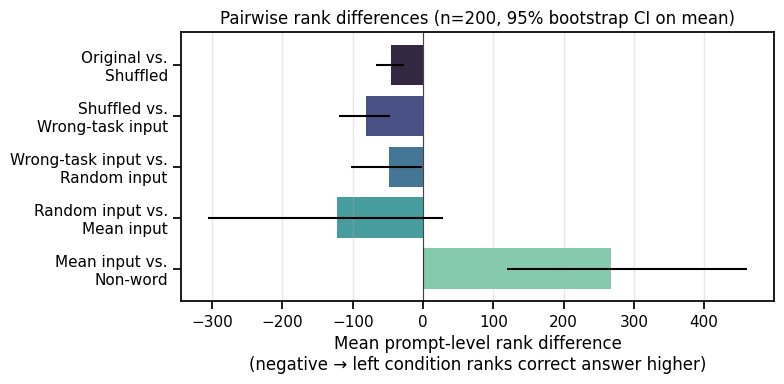

In [10]:
diff_df = pd.DataFrame({
    'Comparison': [r[2] for r in diff_results],
    'Mean':       [r[3] for r in diff_results],
    'Lo':         [r[4] for r in diff_results],
    'Hi':         [r[5] for r in diff_results],
})
diff_df['err_lo'] = diff_df['Mean'] - diff_df['Lo']
diff_df['err_hi'] = diff_df['Hi']   - diff_df['Mean']

fig, ax = plt.subplots(figsize=(6.4*1.25, 4.0))
palette = sns.color_palette('mako', n_colors=len(diff_df))
sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],
            palette=palette, linewidth=0, ax=ax)
ax.errorbar(x=diff_df['Mean'], y=np.arange(len(diff_df)),
            xerr=[diff_df['err_lo'], diff_df['err_hi']], color='black',
            fmt='none')
ax.axvline(0, color='black', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean prompt-level rank difference\n(negative → left condition ranks correct answer higher)')
ax.set_ylabel('')
ax.set_title(f'Pairwise rank differences (n={total_n}, 95% bootstrap CI on mean)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Task-level heterogeneity

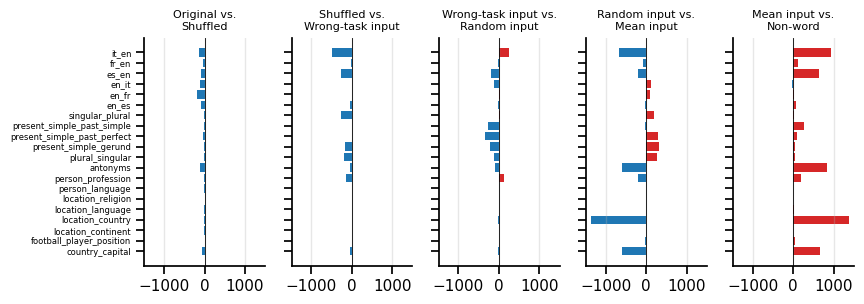

In [8]:
task_list_sorted = sorted(set(prompt_task))
short_task = [t.split('/')[-1] for t in task_list_sorted]

rows = []
for t, short in zip(task_list_sorted, short_task):
    mask = prompt_task == t
    for a, b, label in COMPARISONS:
        rows.append({'task': short, 'comparison': label,
                     'diff': (ranks[a][mask] - ranks[b][mask]).mean()})
het_df = pd.DataFrame(rows)

g = sns.FacetGrid(het_df, col='comparison', col_wrap=len(COMPARISONS),
                  height=3.2, aspect=0.55, sharey=True)
def _bar(data, **kw):
    ax = plt.gca()
    colors = ['tab:blue' if d <= 0 else 'tab:red' for d in data['diff']]
    ax.barh(np.arange(len(data)), data['diff'], color=colors, linewidth=0)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_yticks(np.arange(len(data)))
    ax.set_yticklabels(data['task'], fontsize=6)
    ax.grid(True, alpha=0.3, axis='x')

g.map_dataframe(_bar)
g.set_titles(col_template='{col_name}', size=8)
g.set_axis_labels('', '')
plt.tight_layout(); plt.show()

## Partial shuffling: vary the number of demos with correct pairings

For each prompt, keep k of the 10 demos paired correctly (randomly chosen which k) and shuffle the remaining 10−k demos among themselves. 
At k=0 this equals `shuffled`; at k=10 it equals `orig`. Intermediate values tell you whether the model needs many correctly-paired demos, just a few, or at least some threshold to form a working task vector.

In [11]:
def positions_for_scheme(scheme, k, n_demos):
    if k == 0: return set()
    if k == n_demos: return set(range(n_demos))
    if scheme == 'random':
        return set(rng.sample(range(n_demos), k))
    if scheme == 'first':
        return set(range(k))
    if scheme == 'last':
        return set(range(n_demos - k, n_demos))
    if scheme == 'evenly_spaced':
        return set(np.round(np.linspace(0, n_demos - 1, k)).astype(int).tolist())
    raise ValueError(scheme)

K_VALUES = list(range(0, 11))
SCHEMES = ['random', 'first', 'last', 'evenly_spaced']
ranks_input_pos = {s: {k: [] for k in K_VALUES} for s in SCHEMES}
prompt_task_pos = []

for task_name, splits in tqdm(list(all_splits.items())):
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        n_demos = len(demos)
        
        for scheme in SCHEMES:
            for k in K_VALUES:
                intact = positions_for_scheme(scheme, k, n_demos)
                shuffle_idx = [i for i in range(n_demos) if i not in intact]
                shuffled_inputs = [inputs[i] for i in shuffle_idx]
                rng.shuffle(shuffled_inputs)
                new_inputs = inputs.copy()
                for pos, orig_idx in enumerate(shuffle_idx):
                    new_inputs[orig_idx] = shuffled_inputs[pos]
                
                prompt = build_icl_prompt(list(zip(new_inputs, outputs)), qi)
                tokens = model.to_tokens(prompt, prepend_bos=True)
                last = tokens.shape[1] - 1
                with torch.no_grad():
                    logits = model(tokens)[0, last]
                ranks_input_pos[scheme][k].append(answer_rank(model, logits, ans))
        
        prompt_task_pos.append(task_name)
        torch.cuda.empty_cache()

for s in SCHEMES:
    for k in K_VALUES:
        ranks_input_pos[s][k] = np.array(ranks_input_pos[s][k])
prompt_task_pos = np.array(prompt_task_pos)
n_pos = len(prompt_task_pos)
print(f'\nTotal prompts: {n_pos}')

100%|██████████| 20/20 [05:39<00:00, 16.99s/it]


Total prompts: 200


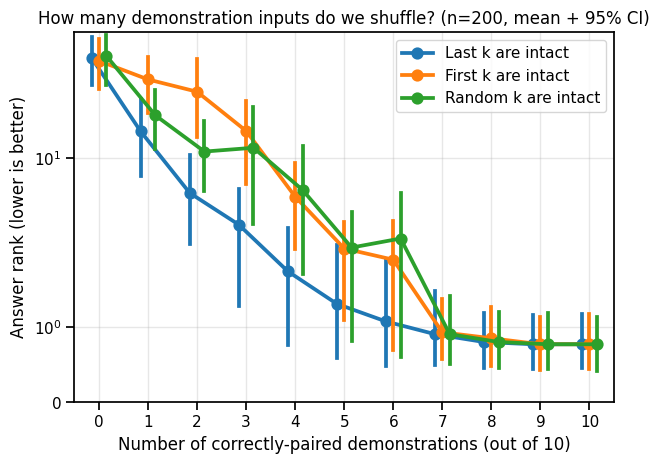

In [12]:
rows = []
for s in SCHEMES[:-1][::-1]:
    for k in K_VALUES:
        for v in ranks_input_pos[s][k]:
            rows.append({'Scheme': s, 'k': k, 'Rank': v})
df_input_pos = pd.DataFrame(rows)

scheme_labels = {
    'random': 'Random k are intact',
    'first':  'First k are intact',
    'last':   'Last k are intact',
}
df_input_pos['Scheme'] = df_input_pos['Scheme'].map(scheme_labels)
label_order = [scheme_labels[s] for s in SCHEMES[:-1][::-1]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.pointplot(data=df_input_pos, x='k', y='Rank', hue='Scheme', hue_order=label_order,
              errorbar=('ci', 95), ax=ax, dodge=0.3)
ax.set_xlabel('Number of correctly-paired demonstrations (out of 10)')
ax.set_ylabel('Answer rank (lower is better)')
ax.set_yscale('symlog')
ax.set_ylim(bottom=0)
ax.set_title(f'How many demonstration inputs do we shuffle? (n={n_pos}, mean + 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='upper right')
plt.tight_layout(); plt.show()

/tmp/ipykernel_2817202/3615249477.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Rank', hue='Scheme', hue_order=label_order, scale=0.5,
/tmp/ipykernel_2817202/3615249477.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Rank', hue='Scheme', hue_order=label_order, scale=0.5,
/tmp/ipykernel_2817202/3615249477.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Rank', hue='Scheme', hu

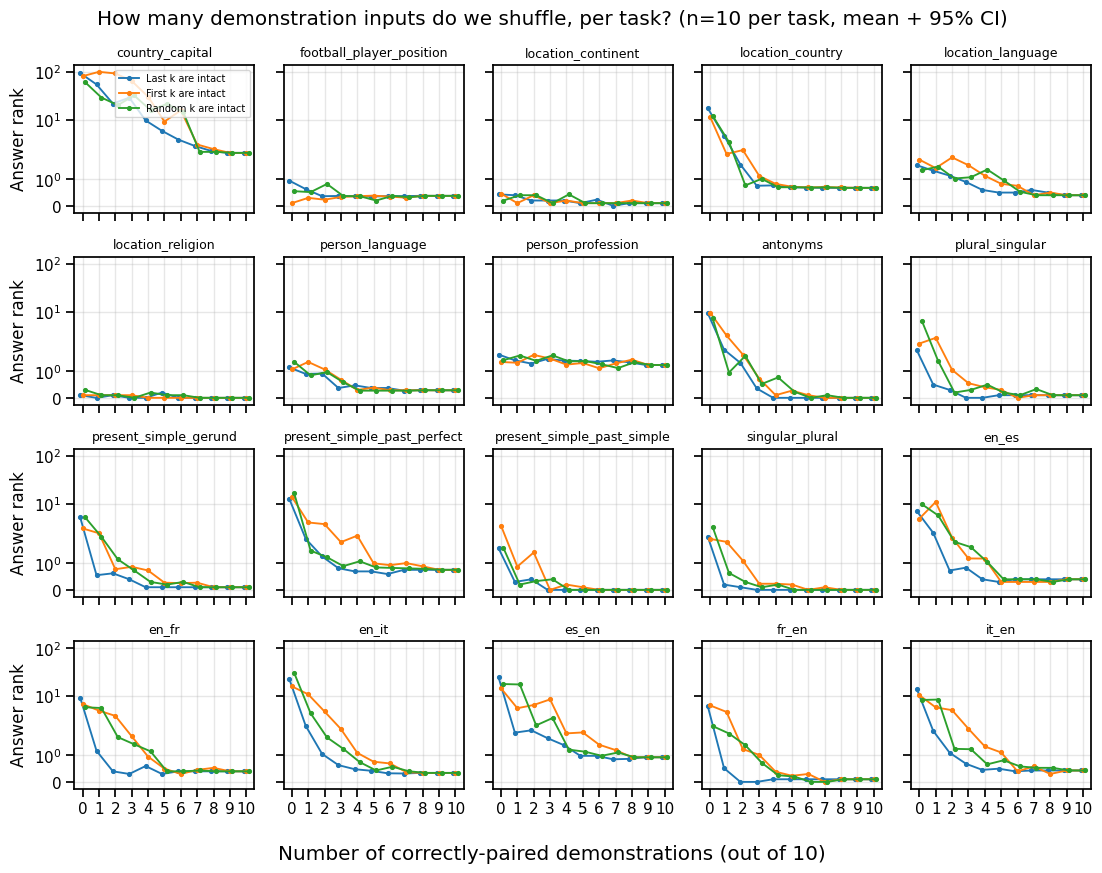

In [14]:
task_list = sorted(set(prompt_task_pos))
n_cols = 5
n_rows = int(np.ceil(len(task_list) / n_cols))

rows = []
for s in SCHEMES[:-1][::-1]:
    for k in K_VALUES:
        for v, t in zip(ranks_input_pos[s][k], prompt_task_pos):
            rows.append({'Scheme': scheme_labels[s], 'k': k, 'task': t, 'Rank': v})
df_input_pos_task = pd.DataFrame(rows)
label_order = [scheme_labels[s] for s in SCHEMES[:-1][::-1]]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list):
    sub = df_input_pos_task[df_input_pos_task['task'] == t]
    sns.pointplot(data=sub, x='k', y='Rank', hue='Scheme', hue_order=label_order, scale=0.5,
                  errorbar=None, ax=ax, dodge=0.3,
                  legend=(ax is axes[0]))
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Answer rank' if ax in axes[::n_cols] else '')
    ax.set_yscale('symlog')
    ax.grid(True, alpha=0.3)

axes[0].legend(title='', loc='upper right', fontsize=7)

for ax in axes[len(task_list):]:
    ax.set_visible(False)

fig.supxlabel('Number of correctly-paired demonstrations (out of 10)')
fig.suptitle(f'How many demonstration inputs do we shuffle, per task? (n={n_pos // len(task_list)} per task, mean + 95% CI)')
plt.tight_layout()
plt.show()

## Partial output shuffling: symmetric manipulation on the output side

For each scheme and k, keep k outputs correctly paired and shuffle the outputs at the remaining 10−k positions among themselves. Inputs stay in original order. This mirrors the input-shuffling experiment on the output side.

In [12]:
ranks_output_pos = {s: {k: [] for k in K_VALUES} for s in SCHEMES}
prompt_task_out = []

for task_name, splits in tqdm(list(all_splits.items())):
    for pdata in splits['icl_prompts'][:10]:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        n_demos = len(demos)
        
        for scheme in SCHEMES:
            for k in K_VALUES:
                intact = positions_for_scheme(scheme, k, n_demos)
                shuffle_idx = [i for i in range(n_demos) if i not in intact]
                shuffled_outputs = [outputs[i] for i in shuffle_idx]
                rng.shuffle(shuffled_outputs)
                new_outputs = outputs.copy()
                for pos, orig_idx in enumerate(shuffle_idx):
                    new_outputs[orig_idx] = shuffled_outputs[pos]
                
                prompt = build_icl_prompt(list(zip(inputs, new_outputs)), qi)
                tokens = model.to_tokens(prompt, prepend_bos=True)
                last = tokens.shape[1] - 1
                with torch.no_grad():
                    logits = model(tokens)[0, last]
                ranks_output_pos[scheme][k].append(answer_rank(model, logits, ans))
        
        prompt_task_out.append(task_name)
        torch.cuda.empty_cache()

for s in SCHEMES:
    for k in K_VALUES:
        ranks_output_pos[s][k] = np.array(ranks_output_pos[s][k])
prompt_task_out = np.array(prompt_task_out)
n_out = len(prompt_task_out)
print(f'\nTotal prompts: {n_out}')

 50%|█████     | 10/20 [03:00<03:00, 18.08s/it]


KeyboardInterrupt: 

### Plot: output-shuffling by position scheme

In [ ]:
rows = []
for s in SCHEMES[:-1][::-1]:
    for k in K_VALUES:
        for v in ranks_output_pos[s][k]:
            rows.append({'Scheme': scheme_labels[s], 'k': k, 'Rank': v})
df_output_pos = pd.DataFrame(rows)
label_order = [scheme_labels[s] for s in SCHEMES[:-1][::-1]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.pointplot(data=df_output_pos, x='k', y='Rank', hue='Scheme', hue_order=label_order,
              errorbar=('ci', 95), ax=ax, dodge=0.3)
ax.set_xlabel('Number of correctly-paired demonstrations (out of 10)')
ax.set_ylabel('Answer rank (lower is better)')
ax.set_yscale('symlog')
ax.set_title(f'How many demonstration outputs do we shuffle? (n={n_out}, mean + 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='upper right')
plt.tight_layout(); plt.show()